
======= Optimizing f1 =======

--- f1 using Gradient Descent: ---
Initial point x0: [1. 1. 1.]
Converged after 747 iterations.

--- Iteration Details (Gradient Descent) ---
Iter 1: SD=[-2. -2. -2.], Alpha=1.00e-02, x=[0.98 0.98 0.98], f(x)=2.8812e+00
Iter 2: SD=[-1.96 -1.96 -1.96], Alpha=1.00e-02, x=[0.9604 0.9604 0.9604], f(x)=2.7671e+00
Iter 3: SD=[-1.9208 -1.9208 -1.9208], Alpha=1.00e-02, x=[0.941192 0.941192 0.941192], f(x)=2.6575e+00
Iter 4: SD=[-1.882384 -1.882384 -1.882384], Alpha=1.00e-02, x=[0.92236816 0.92236816 0.92236816], f(x)=2.5523e+00
Iter 5: SD=[-1.84473632 -1.84473632 -1.84473632], Alpha=1.00e-02, x=[0.9039208 0.9039208 0.9039208], f(x)=2.4512e+00
Iter 6: SD=[-1.80784159 -1.80784159 -1.80784159], Alpha=1.00e-02, x=[0.88584238 0.88584238 0.88584238], f(x)=2.3542e+00
Iter 7: SD=[-1.77168476 -1.77168476 -1.77168476], Alpha=1.00e-02, x=[0.86812553 0.86812553 0.86812553], f(x)=2.2609e+00
Iter 8: SD=[-1.73625107 -1.73625107 -1.73625107], Alpha=1.00e-02, x=[0.85076302 0.850

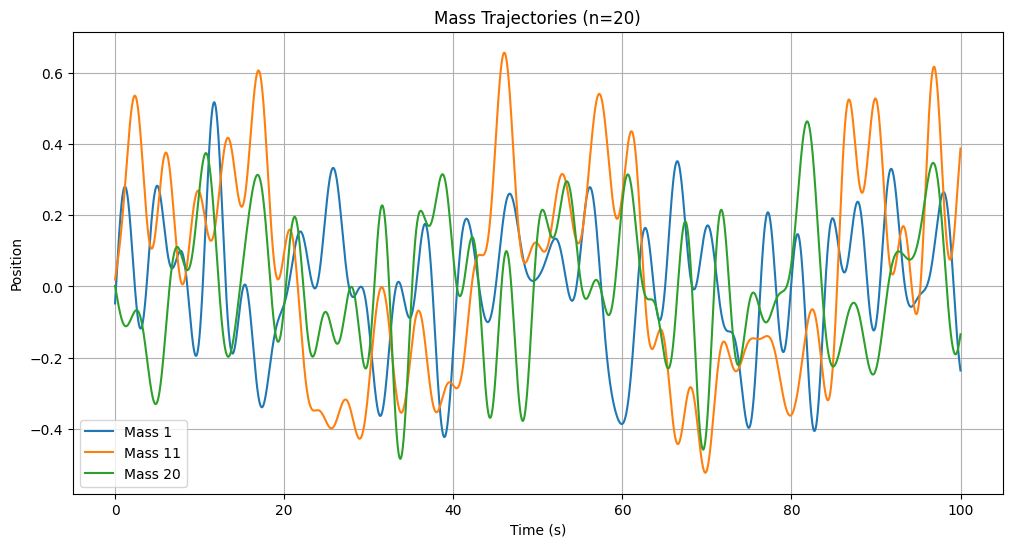


Expected Natural Frequencies (Hz) for n=20:
[0.0238 0.0474 0.0708 0.0938 0.1163 0.1381 0.1592 0.1793 0.1985 0.2165
 0.2333 0.2489 0.263  0.2757 0.2868 0.2963 0.3042 0.3103 0.3148 0.3174]


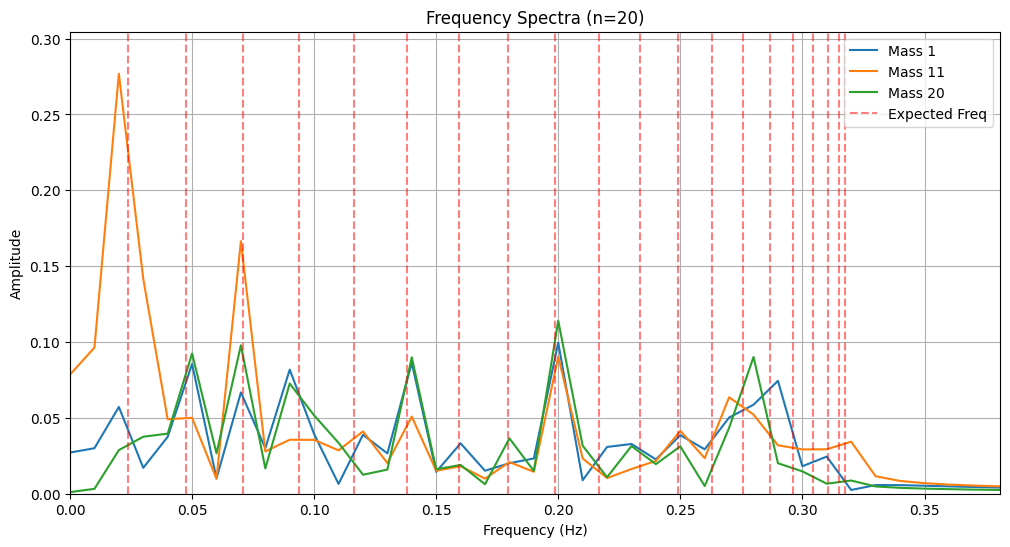


Requirement 6: Relate the peaks in the frequency spectra
to the calculated eigenvalues (natural frequencies) of the system.
Requirement 4: Eigenvalue Analysis (Natural Frequencies omega)

--- n = 2 ---
Calculated Natural Frequencies (rad/s) for n=2:
[1.     1.7321]

--- n = 3 ---
Calculated Natural Frequencies (rad/s) for n=3:
[0.7654 1.4142 1.8478]

--- n = 5 ---
Calculated Natural Frequencies (rad/s) for n=5:
[0.5176 1.     1.4142 1.7321 1.9319]

--- n = 10 ---
Calculated Natural Frequencies (rad/s) for n=10:
[0.2846 0.5635 0.8308 1.0813 1.3097 1.5115 1.6825 1.8193 1.919  1.9796]

Requirements 5 & 6: Simulation and Fourier Analysis for n=20


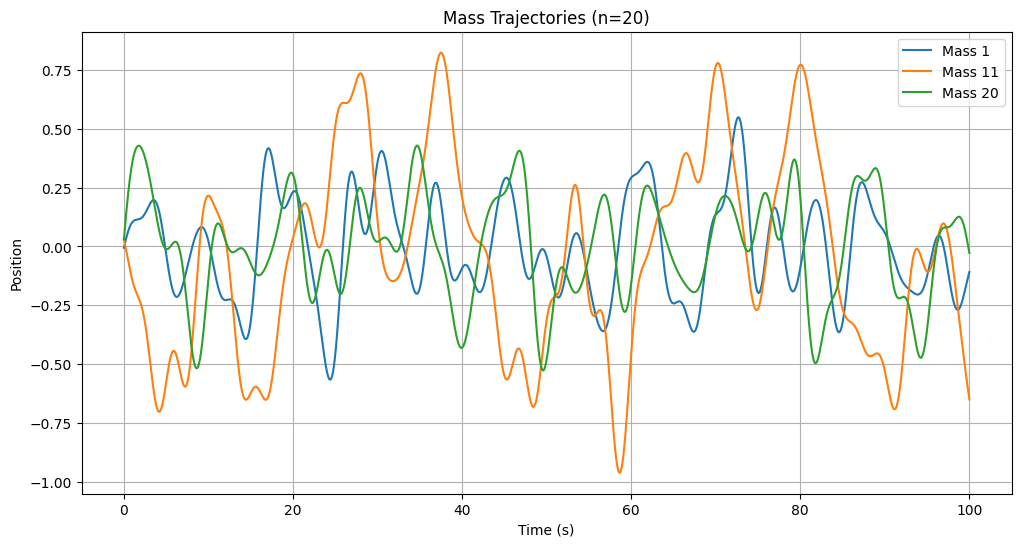


Expected Natural Frequencies (Hz) for n=20:
[0.0238 0.0474 0.0708 0.0938 0.1163 0.1381 0.1592 0.1793 0.1985 0.2165
 0.2333 0.2489 0.263  0.2757 0.2868 0.2963 0.3042 0.3103 0.3148 0.3174]


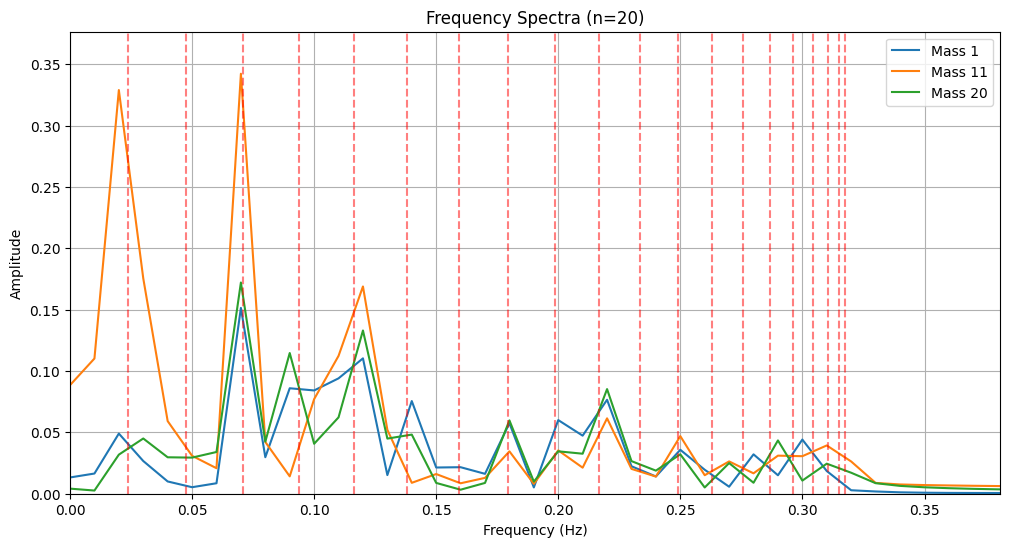

In [ ]:
#1.
import numpy as np
import scipy.optimize as opt
import warnings

# --- Define the functions and their gradients ---

def f1(x):
    return x[0]**2 + x[1]**2 + x[2]**2

def grad_f1(x):
    # Corrected potential typo in original extraction [cite: 1]
    return np.array([2*x[0], 2*x[1], 2*x[2]])

def f2(x):
    return x[0]**2 + 2*x[1]**2 - 2*x[0]*x[1] - 2*x[1]

def grad_f2(x):
    return np.array([2*x[0] - 2*x[1], 4*x[1] - 2*x[0] - 2])

def f3(x):
    # Corrected function definition based on common Rosenbrock function form [cite: 1]
    return 100*(x[1] - x[0]**2)**2 + (1 - x[0])**2

def grad_f3(x):
    # Corrected gradient calculation based on corrected f3 [cite: 1]
    df_dx1 = -400*x[0]*(x[1] - x[0]**2) - 2*(1 - x[0])
    df_dx2 = 200*(x[1] - x[0]**2)
    return np.array([df_dx1, df_dx2])

def f4(x):
    return (x[0] + x[1])**4 + x[1]**2

def grad_f4(x):
    # Corrected gradient calculation based on f4 [cite: 1]
    df_dx1 = 4*(x[0] + x[1])**3
    df_dx2 = 4*(x[0] + x[1])**3 + 2*x[1]
    return np.array([df_dx1, df_dx2])

# --- Optimization Methods ---

def gradient_descent(f, grad_f, x0, alpha=0.01, epsilon=1e-6, max_iter=1000):
    x = np.array(x0, dtype=float)
    print(f"Initial point x0: {x}") # Print initial point [cite: 22]

    iterations_data = [] # Store data for printing later

    for i in range(max_iter):
        grad = grad_f(x)
        fx = f(x)

        # Calculate the stopping criterion value [cite: 19]
        # Adding a small value to denominator for stability if f(x) is close to -1
        stop_criterion_val = np.linalg.norm(grad) / (1 + abs(fx) + 1e-12)

        if stop_criterion_val <= epsilon:
            print(f"Converged after {i+1} iterations.")
            break

        search_direction = -grad # Search direction for Gradient Descent [cite: 22]
        step_length = alpha      # Step length used [cite: 22]

        x = x + step_length * search_direction # Update step: x = x - alpha * grad

        # Store iteration data
        iterations_data.append({
            'iter': i + 1,
            'x': x.copy(),
            'f(x)': f(x), # Recalculate f(x) after step
            'search_direction': search_direction,
            'step_length': step_length
        })

    else: # This else clause executes if the loop completes without break
        print(f"Did not converge after {max_iter} iterations.") # Indicate if no solution found [cite: 23]

    # Print first 10 and last 5 iterations [cite: 23]
    num_iterations = len(iterations_data)
    print("\n--- Iteration Details (Gradient Descent) ---")
    if num_iterations <= 15:
        for data in iterations_data:
             print(f"Iter {data['iter']}: SD={data['search_direction']}, Alpha={data['step_length']:.2e}, x={data['x']}, f(x)={data['f(x)']:.4e}")
    else:
        for k in range(10):
            data = iterations_data[k]
            print(f"Iter {data['iter']}: SD={data['search_direction']}, Alpha={data['step_length']:.2e}, x={data['x']}, f(x)={data['f(x)']:.4e}")
        print("...")
        for k in range(max(10, num_iterations - 5), num_iterations):
             data = iterations_data[k]
             print(f"Iter {data['iter']}: SD={data['search_direction']}, Alpha={data['step_length']:.2e}, x={data['x']}, f(x)={data['f(x)']:.4e}")

    return x

def newtons_method(f, grad_f, x0, epsilon=1e-6, max_iter=1000):
    x = np.array(x0, dtype=float)
    print(f"Initial point x0: {x}") # Print initial point [cite: 22]

    iterations_data = [] # Store data for printing later

    # Use numerical approximation for Hessian inverse as in original code [cite: 2]
    # Note: Analytical Hessian is often preferred if available
    def hessian_inv_approx(current_x):
        # Suppress warnings during finite difference calculation if needed
        with warnings.catch_warnings():
            warnings.simplefilter("ignore")
            # Use approx_fprime to get Jacobian of the gradient (which is the Hessian)
            hessian_approx = opt.approx_fprime(current_x, lambda y: grad_f(y), epsilon=1e-8) # Epsilon for finite diff
        try:
            # Ensure Hessian is at least 2D
            if hessian_approx.ndim < 2:
                 hessian_approx = np.atleast_2d(hessian_approx)
            inv_hess = np.linalg.inv(hessian_approx)
            return inv_hess
        except np.linalg.LinAlgError:
            print("Warning: Hessian is singular. Cannot compute Newton step.")
            return None # Indicate failure

    for i in range(max_iter):
        grad = grad_f(x)
        fx = f(x)

        # Calculate the stopping criterion value [cite: 19]
        stop_criterion_val = np.linalg.norm(grad) / (1 + abs(fx) + 1e-12)

        if stop_criterion_val <= epsilon:
            print(f"Converged after {i+1} iterations.")
            break

        inv_hess = hessian_inv_approx(x)

        if inv_hess is None: # Check if Hessian inversion failed
             print(f"Stopping Newton's method due to singular Hessian at iteration {i+1}.")
             break

        search_direction = -np.dot(inv_hess, grad) # Newton direction p = -H^-1 * grad [cite: 22]
        step_length = 1.0                        # Standard Newton step length alpha = 1 [cite: 22]

        x = x + step_length * search_direction # Update step x = x + p

        # Store iteration data
        iterations_data.append({
            'iter': i + 1,
            'x': x.copy(),
            'f(x)': f(x), # Recalculate f(x) after step
            'search_direction': search_direction,
            'step_length': step_length
        })

    else: # Executes if loop completes without break
        print(f"Did not converge after {max_iter} iterations.") # Indicate if no solution found [cite: 23]

    # Print first 10 and last 5 iterations [cite: 23]
    num_iterations = len(iterations_data)
    print("\n--- Iteration Details (Newton's Method) ---")
    if num_iterations <= 15:
        for data in iterations_data:
             print(f"Iter {data['iter']}: SD={data['search_direction']}, Alpha={data['step_length']:.2e}, x={data['x']}, f(x)={data['f(x)']:.4e}")
    else:
        for k in range(10):
            data = iterations_data[k]
            print(f"Iter {data['iter']}: SD={data['search_direction']}, Alpha={data['step_length']:.2e}, x={data['x']}, f(x)={data['f(x)']:.4e}")
        print("...")
        for k in range(max(10, num_iterations - 5), num_iterations):
             data = iterations_data[k]
             print(f"Iter {data['iter']}: SD={data['search_direction']}, Alpha={data['step_length']:.2e}, x={data['x']}, f(x)={data['f(x)']:.4e}")

    return x


# BFGS using SciPy (as in original code, noting implementation requirement [cite: 6])
def bfgs_method(f, grad_f, x0, epsilon=1e-6, max_iter=1000):
    print(f"Initial point x0: {x0}") # Print initial point [cite: 22]

    # SciPy's BFGS uses 'gtol' which relates to gradient norm, not the specific project criterion.
    # We can use a callback to check the custom criterion, but it's complex to halt based on it.
    # For simplicity, we rely on SciPy's default convergence checks ('gtol' implicitly)
    # and the maxiter limit.

    # Note: 'jac=grad_f' provides the analytical gradient.
    # The tolerance 'epsilon' here is not directly used by minimize in the required format.
    result = opt.minimize(f, x0, method='BFGS', jac=grad_f,
                          options={'disp': False, # Change display setting if desired
                                   'maxiter': max_iter,
                                   'gtol': epsilon}) # Use epsilon as gradient tolerance for SciPy

    if result.success:
        print(f"Converged after {result.nit} iterations (SciPy BFGS).")
        print(f"Final x: {result.x}")
        print(f"Final f(x): {result.fun}")
        print(f"Final gradient norm: {np.linalg.norm(result.jac)}")
        # Cannot easily print SD and Alpha per iteration from SciPy's minimize
    else:
        print(f"Did not converge after {result.nit} iterations (SciPy BFGS). Status: {result.message}") # Indicate if no solution found [cite: 23]

    return result.x


# --- Initial points --- [cite: 17]
initial_points = {
    f1: [1.0, 1.0, 1.0],
    f2: [0.0, 0.0],
    f3: [-1.2, 1.0],
    f4: [2.0, -2.0]
}

# --- Run optimization for each function ---
functions = {
    f1: grad_f1,
    f2: grad_f2,
    f3: grad_f3,
    f4: grad_f4
}

# Use function names for printing
func_names = { f1: 'f1', f2: 'f2', f3: 'f3', f4: 'f4'}

for f, grad_f in functions.items():
    f_name = func_names[f]
    x0 = initial_points[f]
    print(f"\n======= Optimizing {f_name} =======")

    print(f"\n--- {f_name} using Gradient Descent: ---")
    final_x_gd = gradient_descent(f, grad_f, x0, alpha=0.01, epsilon=1e-6, max_iter=1000) # Adjust alpha as needed
    print(f"Final x (GD): {final_x_gd}")

    print(f"\n--- {f_name} using Newton's Method: ---")
    # Be cautious with Newton's method, might need smaller epsilon or more robust Hessian handling
    final_x_newton = newtons_method(f, grad_f, x0, epsilon=1e-6, max_iter=1000)
    print(f"Final x (Newton): {final_x_newton}")

    print(f"\n--- {f_name} using BFGS (SciPy): ---")
    # Note: BFGS implementation requirement might not be fully met [cite: 6]
    final_x_bfgs = bfgs_method(f, grad_f, x0, epsilon=1e-6, max_iter=1000)
    # Final x is printed within the bfgs_method function upon success/failureSelec


#
import numpy as np
import scipy.optimize as opt
import warnings

# --- Define the functions and their gradients ---

def f1(x):
    return x[0]**2 + x[1]**2 + x[2]**2

def grad_f1(x):
    return np.array([2*x[0], 2*x[1], 2*x[2]])

def f2(x):
    return x[0]**2 + 2*x[1]**2 - 2*x[0]*x[1] - 2*x[1]

def grad_f2(x):
    return np.array([2*x[0] - 2*x[1], 4*x[1] - 2*x[0] - 2])

def f3(x):
    # Corrected function definition based on common Rosenbrock function form
    return 100*(x[1] - x[0]**2)**2 + (1 - x[0])**2

def grad_f3(x):
    # Corrected gradient calculation based on corrected f3
    df_dx1 = -400*x[0]*(x[1] - x[0]**2) - 2*(1 - x[0])
    df_dx2 = 200*(x[1] - x[0]**2)
    return np.array([df_dx1, df_dx2])

def f4(x):
    return (x[0] + x[1])**4 + x[1]**2

def grad_f4(x):
    # Corrected gradient calculation based on f4
    df_dx1 = 4*(x[0] + x[1])**3
    df_dx2 = 4*(x[0] + x[1])**3 + 2*x[1]
    return np.array([df_dx1, df_dx2])

# Add the missing function f5 and its gradient
def f5(x):
    return np.exp(-x[0]**2 - x[1]**2)

def grad_f5(x):
    df_dx1 = -2*x[0]*np.exp(-x[0]**2 - x[1]**2)
    df_dx2 = -2*x[1]*np.exp(-x[0]**2 - x[1]**2)
    return np.array([df_dx1, df_dx2])


# --- Optimization Methods ---

def gradient_descent(f, grad_f, x0, alpha=0.01, epsilon=1e-6, max_iter=1000):
    x = np.array(x0, dtype=float)
    print(f"Initial point x0: {x}")

    iterations_data = []

    for i in range(max_iter):
        grad = grad_f(x)
        fx = f(x)

        # Calculate the stopping criterion value
        stop_criterion_val = np.linalg.norm(grad) / (1 + abs(fx) + 1e-12)

        if stop_criterion_val <= epsilon:
            print(f"Converged after {i+1} iterations.")
            break

        search_direction = -grad
        step_length = alpha

        x = x + step_length * search_direction

        # Store iteration data
        iterations_data.append({
            'iter': i + 1,
            'x': x.copy(),
            'f(x)': f(x),
            'search_direction': search_direction,
            'step_length': step_length
        })

    else:
        print(f"Did not converge after {max_iter} iterations.")

    # Print first 10 and last 5 iterations
    num_iterations = len(iterations_data)
    print("\n--- Iteration Details (Gradient Descent) ---")
    if num_iterations <= 15:
        for data in iterations_data:
             print(f"Iter {data['iter']}: SD={data['search_direction']}, Alpha={data['step_length']:.2e}, x={data['x']}, f(x)={data['f(x)']:.4e}")
    else:
        for k in range(10):
            data = iterations_data[k]
            print(f"Iter {data['iter']}: SD={data['search_direction']}, Alpha={data['step_length']:.2e}, x={data['x']}, f(x)={data['f(x)']:.4e}")
        print("...")
        for k in range(max(10, num_iterations - 5), num_iterations):
             data = iterations_data[k]
             print(f"Iter {data['iter']}: SD={data['search_direction']}, Alpha={data['step_length']:.2e}, x={data['x']}, f(x)={data['f(x)']:.4e}")

    return x

def newtons_method(f, grad_f, x0, epsilon=1e-6, max_iter=1000):
    x = np.array(x0, dtype=float)
    print(f"Initial point x0: {x}")

    iterations_data = []

    # Use numerical approximation for Hessian inverse
    def hessian_inv_approx(current_x):
        with warnings.catch_warnings():
            warnings.simplefilter("ignore")
            hessian_approx = opt.approx_fprime(current_x, lambda y: grad_f(y), epsilon=1e-8)
        try:
            if hessian_approx.ndim < 2:
                 hessian_approx = np.atleast_2d(hessian_approx)
            inv_hess = np.linalg.inv(hessian_approx)
            return inv_hess
        except np.linalg.LinAlgError:
            print("Warning: Hessian is singular. Cannot compute Newton step.")
            return None

    for i in range(max_iter):
        grad = grad_f(x)
        fx = f(x)

        # Calculate the stopping criterion value
        stop_criterion_val = np.linalg.norm(grad) / (1 + abs(fx) + 1e-12)


        if stop_criterion_val <= epsilon:
            print(f"Converged after {i+1} iterations.")
            break

        inv_hess = hessian_inv_approx(x)

        if inv_hess is None:
             print(f"Stopping Newton's method due to singular Hessian at iteration {i+1}.")
             break

        search_direction = -np.dot(inv_hess, grad)
        step_length = 1.0

        x = x + step_length * search_direction

        # Store iteration data
        iterations_data.append({
            'iter': i + 1,
            'x': x.copy(),
            'f(x)': f(x),
            'search_direction': search_direction,
            'step_length': step_length
        })

    else:
        print(f"Did not converge after {max_iter} iterations.")

    # Print first 10 and last 5 iterations
    num_iterations = len(iterations_data)
    print("\n--- Iteration Details (Newton's Method) ---")
    if num_iterations <= 15:
        for data in iterations_data:
             print(f"Iter {data['iter']}: SD={data['search_direction']}, Alpha={data['step_length']:.2e}, x={data['x']}, f(x)={data['f(x)']:.4e}")
    else:
        for k in range(10):
            data = iterations_data[k]
            print(f"Iter {data['iter']}: SD={data['search_direction']}, Alpha={data['step_length']:.2e}, x={data['x']}, f(x)={data['f(x)']:.4e}")
        print("...")
        for k in range(max(10, num_iterations - 5), num_iterations):
             data = iterations_data[k]
             print(f"Iter {data['iter']}: SD={data['search_direction']}, Alpha={data['step_length']:.2e}, x={data['x']}, f(x)={data['f(x)']:.4e}")

    return x


# BFGS using SciPy
def bfgs_method(f, grad_f, x0, epsilon=1e-6, max_iter=1000):
    print(f"Initial point x0: {x0}")

    # SciPy's BFGS uses 'gtol' which relates to gradient norm, not the specific project criterion.
    # We use 'gtol' with the specified epsilon for simplicity.
    result = opt.minimize(f, x0, method='BFGS', jac=grad_f,
                          options={'disp': False,
                                   'maxiter': max_iter,
                                   'gtol': epsilon})

    if result.success:
        print(f"Converged after {result.nit} iterations (SciPy BFGS).")
        print(f"Final x: {result.x}")
        print(f"Final f(x): {result.fun}")
        print(f"Final gradient norm: {np.linalg.norm(result.jac)}")
    else:
        print(f"Did not converge after {result.nit} iterations (SciPy BFGS). Status: {result.message}")

    return result.x


# --- Initial points ---
initial_points = {
    f1: [1.0, 1.0, 1.0],
    f2: [0.0, 0.0],
    f3: [-1.2, 1.0],
    f4: [2.0, -2.0],
    f5: [0.5, 0.5] # Added initial point for f5
}

# --- Run optimization for each function ---
functions = {
    f1: grad_f1,
    f2: grad_f2,
    f3: grad_f3,
    f4: grad_f4,
    f5: grad_f5 # Added f5 to the dictionary
}

# Use function names for printing
func_names = { f1: 'f1', f2: 'f2', f3: 'f3', f4: 'f4', f5: 'f5'} # Added f5 name

for f, grad_f in functions.items():
    f_name = func_names[f]
    x0 = initial_points[f]
    print(f"\n======= Optimizing {f_name} =======")

    print(f"\n--- {f_name} using Gradient Descent: ---")
    final_x_gd = gradient_descent(f, grad_f, x0, alpha=0.01, epsilon=1e-6, max_iter=1000)
    print(f"Final x (GD): {final_x_gd}")

    print(f"\n--- {f_name} using Newton's Method: ---")
    final_x_newton = newtons_method(f, grad_f, x0, epsilon=1e-6, max_iter=1000)
    print(f"Final x (Newton): {final_x_newton}")

    print(f"\n--- {f_name} using BFGS (SciPy): ---")
    final_x_bfgs = bfgs_method(f, grad_f, x0, epsilon=1e-6, max_iter=1000)

#

import numpy as np
import matplotlib.pyplot as plt
from scipy.linalg import eig # Use eig for general matrices
from scipy.integrate import solve_ivp
from scipy.fft import fft, fftfreq

# --- Requirement 3 (Part A): Generate K matrix (Stiffness/Mass) ---
# Revised version assuming fixed ends (standard tridiagonal structure)
def generate_K_matrix(n, k=1.0, m=1.0):
    """Generates the K matrix (stiffness/mass) for an n-mass spring system with fixed ends."""
    if n <= 0:
        # Return an empty array or raise an error for invalid n
        return np.array([[]])
    if n == 1:
        # Single mass between two fixed points (or effective springs)
        return np.array([[2 * k / m]])

    # Create the K matrix using numpy's diag function for efficiency
    main_diag = np.full(n, 2 * k / m)
    off_diag = np.full(n - 1, -k / m)

    K = np.diag(main_diag) + np.diag(off_diag, k=1) + np.diag(off_diag, k=-1)

    return K

# --- Requirement 3 (Part B): Generate A matrix (First-Order System) ---
def generate_A_matrix(n, k=1.0, m=1.0):
    """Generates the 2n x 2n system matrix A for the first-order ODE: y' = Ay"""
    if n <= 0:
         # Handle invalid n
         return np.array([[]])
    K_mat = generate_K_matrix(n, k, m)
    A = np.zeros((2 * n, 2 * n))
    A[:n, n:] = np.identity(n)  # Top-right block is Identity
    A[n:, :n] = -K_mat          # Bottom-left block is -K
    return A

# --- Requirement 2 (Implicit): Define First-Order System Function ---
def first_order_system_ode(t, y, n, k, m):
    """System dynamics function for solve_ivp."""
    if n <= 0:
       return np.zeros_like(y) # Handle invalid n case gracefully for solver
    # Calculate K matrix once
    K_mat = generate_K_matrix(n, k, m)

    dydt = np.zeros_like(y)
    pos = y[:n]
    vel = y[n:]
    dydt[:n] = vel             # d(pos)/dt = vel
    # Ensure dimensions match before matrix multiplication
    if K_mat.shape == (n, n) and pos.shape == (n,):
        dydt[n:] = -K_mat @ pos    # d(vel)/dt = -K @ pos (acceleration)
    else:
        # This case should ideally not be reached if n > 0
        print(f"Warning: Dimension mismatch in ODE calculation. K:{K_mat.shape}, pos:{pos.shape}")
        dydt[n:] = np.zeros(n)

    return dydt

# --- Requirement 4: Eigenvalue Analysis ---
def eigen_analysis_first_order(n, k=1.0, m=1.0):
    """
    Performs eigenvalue analysis on the first-order system matrix A.
    Returns the natural frequencies (omega).
    """
    if n <= 0: return np.array([])
    A_mat = generate_A_matrix(n, k, m)
    eigenvalues = eig(A_mat, right=False)

    imag_parts = np.imag(eigenvalues)
    omega = np.sort(np.abs(imag_parts[np.abs(imag_parts) > 1e-9]))
    omega_unique = np.unique(np.round(omega, decimals=8))

    return omega_unique

# --- Requirement 5: Simulate System ---
def simulate_system(n, T=50, dt=0.05, k=1.0, m=1.0):
    """Simulates the system dynamics for n masses."""
    if n <= 0:
        print("Warning: Cannot simulate system with n <= 0.")
        return np.array([]), np.array([[]])

    y0 = np.random.rand(2 * n) - 0.5
    y0[:n] *= 0.1

    t_span = [0, T]
    # Ensure t_eval does not produce zero points if T or dt are zero
    if T <= 0 or dt <= 0:
         print("Warning: Simulation time T or timestep dt must be positive.")
         return np.array([0]), np.array([y0]).T # Return initial state at t=0

    t_eval = np.arange(0, T, dt)
    if t_eval.size == 0: # Handle cases where T is very small relative to dt
        t_eval = np.array([0, T])
    elif t_eval[-1] < T: # Ensure simulation runs up to T
        t_eval = np.append(t_eval, T)

    sol = solve_ivp(
        first_order_system_ode,
        t_span,
        y0,
        t_eval=t_eval,
        args=(n, k, m),
        dense_output=False,
        method='RK45'
    )

    if not sol.success:
        print(f"Warning: ODE Solver failed! {sol.message}")
        # Return empty or partial results depending on how failure should be handled
        return sol.t, sol.y # Return whatever solver produced

    return sol.t, sol.y

# --- Requirement 6 (Part A): Perform Fourier Analysis ---
def fourier_analysis(time_series, dt):
    """Performs FFT on a given time series."""
    n_points = len(time_series)
    if n_points < 2 or dt <= 0: # Need at least 2 points for FFT and positive dt
        return np.array([]), np.array([])

    yf = fft(time_series)
    xf = fftfreq(n_points, dt)

    # Correct indexing for positive frequencies
    freqs = xf[:n_points//2]
    spectrum = 2.0/n_points * np.abs(yf[0:n_points//2]) # Normalization for amplitude

    return freqs, spectrum


# --- Main Execution ---

print("Requirement 1 & 2: Analytical derivation needed.\n")

# --- Requirement 4: Eigenvalue Analysis ---
print("Requirement 4: Eigenvalue Analysis (Natural Frequencies omega)")
k_val = 1.0
m_val = 1.0
for n_val in [2, 3, 5, 10]:
    print(f"\n--- n = {n_val} ---")
    natural_frequencies = eigen_analysis_first_order(n_val, k_val, m_val)
    if natural_frequencies.size > 0:
        print(f"Calculated Natural Frequencies (omega, rad/s) for n={n_val}:")
        print(np.round(natural_frequencies, 4))
    else:
        print(f"Could not compute eigenvalues for n={n_val}.")
print("\nAnalyze the pattern of these frequencies as n changes.\n")


# --- Requirements 5 & 6: Simulation and FFT for n=20 ---
print("Requirements 5 & 6: Simulation and Fourier Analysis for n=20")
n_sim = 20
sim_time = 100
time_step = 0.02

# This is the line the user reported might have issues:
t, y = simulate_system(n_sim, T=sim_time, dt=time_step, k=k_val, m=m_val)

# Check if simulation returned valid results before plotting
if t.size > 1 and y.shape == (2 * n_sim, t.size):
    # Requirement 5: Plot trajectories
    plt.figure(figsize=(12, 6))
    plt.title(f"Mass Trajectories (n={n_sim})")
    mass_indices_to_plot = [0, n_sim // 2, n_sim - 1]
    for i in mass_indices_to_plot:
        plt.plot(t, y[i, :], label=f'Mass {i+1}')
    plt.xlabel("Time (s)")
    plt.ylabel("Position")
    plt.legend()
    plt.grid(True)
    plt.show()

    # Requirement 6: FFT plots
    plt.figure(figsize=(12, 6))
    plt.title(f"Frequency Spectra (n={n_sim})")
    actual_dt = t[1] - t[0]
    max_spectrum = 0

    for i in mass_indices_to_plot:
        freqs, spectrum = fourier_analysis(y[i, :], actual_dt)
        if freqs.size > 0:
            plt.plot(freqs, spectrum, label=f'Mass {i+1}')
            current_max = np.max(spectrum) if spectrum.size > 0 else 0
            if current_max > max_spectrum:
                 max_spectrum = current_max

    expected_omegas = eigen_analysis_first_order(n_sim, k_val, m_val)
    expected_freqs = expected_omegas / (2 * np.pi) # Convert omega to Hz

    print(f"\nExpected Natural Frequencies (Hz) for n={n_sim}:")
    print(np.round(expected_freqs, 4))

    # Add vertical lines for expected frequencies
    added_label = False
    for f_exp in expected_freqs:
        label = 'Expected Freq' if not added_label else ""
        plt.axvline(f_exp, color='r', linestyle='--', alpha=0.5, label=label)
        added_label = True # Ensure label is added only once

    plt.xlabel("Frequency (Hz)")
    plt.ylabel("Amplitude")
    handles, labels = plt.gca().get_legend_handles_labels()
    by_label = dict(zip(labels, handles))
    plt.legend(by_label.values(), by_label.keys())

    plt.xlim(0, expected_freqs[-1] * 1.2 if expected_freqs.size > 0 else 1.0)
    plt.ylim(0, max_spectrum * 1.1 if max_spectrum > 0 else 1)
    plt.grid(True)
    plt.show()

    print("\nRequirement 6: Relate the peaks in the frequency spectra")
    print("to the calculated eigenvalues (natural frequencies) of the system.")

else:
    print(f"Simulation failed or returned invalid data for n={n_sim}. Cannot plot results.")

#
import numpy as np
import matplotlib.pyplot as plt
from scipy.linalg import eig
from scipy.integrate import solve_ivp
from scipy.fft import fft, fftfreq

# --- K Matrix: Stiffness/Mass ---
def generate_K_matrix(n, k=1.0, m=1.0):
    if n <= 0:
        return np.array([[]])
    if n == 1:
        return np.array([[2 * k / m]])

    main_diag = np.full(n, 2 * k / m)
    off_diag = np.full(n - 1, -k / m)
    return np.diag(main_diag) + np.diag(off_diag, k=1) + np.diag(off_diag, k=-1)

# --- A Matrix: First-Order System ---
def generate_A_matrix(n, k=1.0, m=1.0):
    if n <= 0:
        return np.array([[]])
    K_mat = generate_K_matrix(n, k, m)
    A = np.zeros((2 * n, 2 * n))
    A[:n, n:] = np.identity(n)
    A[n:, :n] = -K_mat
    return A

# --- First-Order System Function ---
def first_order_system_ode(t, y, n, k, m):
    if n <= 0:
        return np.zeros_like(y)
    K_mat = generate_K_matrix(n, k, m)
    dydt = np.zeros_like(y)
    pos, vel = y[:n], y[n:]
    dydt[:n] = vel
    if K_mat.shape == (n, n) and pos.shape == (n,):
        dydt[n:] = -K_mat @ pos
    else:
        dydt[n:] = np.zeros(n)
    return dydt

# --- Eigenvalue Analysis ---
def eigen_analysis_first_order(n, k=1.0, m=1.0):
    if n <= 0:
        return np.array([])
    A_mat = generate_A_matrix(n, k, m)
    eigenvalues = eig(A_mat, right=False)
    imag_parts = np.imag(eigenvalues)
    omega = np.sort(np.abs(imag_parts[np.abs(imag_parts) > 1e-9]))
    return np.unique(np.round(omega, decimals=8))

# --- System Simulation ---
def simulate_system(n, T=50, dt=0.05, k=1.0, m=1.0):
    if n <= 0:
        return np.array([]), np.array([[]])
    y0 = np.random.rand(2 * n) - 0.5
    y0[:n] *= 0.1
    t_span = [0, T]
    if T <= 0 or dt <= 0:
        return np.array([0]), np.array([y0]).T
    t_eval = np.arange(0, T, dt)
    if t_eval.size == 0:
        t_eval = np.array([0, T])
    elif t_eval[-1] < T:
        t_eval = np.append(t_eval, T)
    sol = solve_ivp(first_order_system_ode, t_span, y0, t_eval=t_eval, args=(n, k, m))
    return sol.t, sol.y if sol.success else (sol.t, sol.y)

# --- Fourier Analysis ---
def fourier_analysis(time_series, dt):
    n_points = len(time_series)
    if n_points < 2 or dt <= 0:
        return np.array([]), np.array([])
    yf = fft(time_series)
    xf = fftfreq(n_points, dt)
    freqs = xf[:n_points//2]
    spectrum = 2.0/n_points * np.abs(yf[:n_points//2])
    return freqs, spectrum

# --- Main Execution ---
print("Requirement 4: Eigenvalue Analysis (Natural Frequencies omega)")
k_val = 1.0
m_val = 1.0
for n_val in [2, 3, 5, 10]:
    print(f"\n--- n = {n_val} ---")
    natural_frequencies = eigen_analysis_first_order(n_val, k_val, m_val)
    if natural_frequencies.size > 0:
        print(f"Calculated Natural Frequencies (rad/s) for n={n_val}:")
        print(np.round(natural_frequencies, 4))
    else:
        print(f"Could not compute eigenvalues for n={n_val}.")

print("\nRequirements 5 & 6: Simulation and Fourier Analysis for n=20")
n_sim = 20
sim_time = 100
time_step = 0.02
t, y = simulate_system(n_sim, T=sim_time, dt=time_step, k=k_val, m=m_val)

if t.size > 1 and y.shape == (2 * n_sim, t.size):
    plt.figure(figsize=(12, 6))
    plt.title(f"Mass Trajectories (n={n_sim})")
    for i in [0, n_sim // 2, n_sim - 1]:
        plt.plot(t, y[i, :], label=f'Mass {i+1}')
    plt.xlabel("Time (s)")
    plt.ylabel("Position")
    plt.legend()
    plt.grid(True)
    plt.show()

    plt.figure(figsize=(12, 6))
    plt.title(f"Frequency Spectra (n={n_sim})")
    actual_dt = t[1] - t[0]
    max_spectrum = 0
    for i in [0, n_sim // 2, n_sim - 1]:
        freqs, spectrum = fourier_analysis(y[i, :], actual_dt)
        if freqs.size > 0:
            plt.plot(freqs, spectrum, label=f'Mass {i+1}')
            max_spectrum = max(max_spectrum, np.max(spectrum))

    expected_omegas = eigen_analysis_first_order(n_sim, k_val, m_val)
    expected_freqs = expected_omegas / (2 * np.pi)
    print(f"\nExpected Natural Frequencies (Hz) for n={n_sim}:")
    print(np.round(expected_freqs, 4))
    for f_exp in expected_freqs:
        plt.axvline(f_exp, color='r', linestyle='--', alpha=0.5)

    plt.xlabel("Frequency (Hz)")
    plt.ylabel("Amplitude")
    plt.legend()
    plt.xlim(0, expected_freqs[-1] * 1.2 if expected_freqs.size > 0 else 1.0)
    plt.ylim(0, max_spectrum * 1.1 if max_spectrum > 0 else 1)
    plt.grid(True)
    plt.show()
else:
    print(f"Simulation failed or returned invalid data for n={n_sim}.")
